In [280]:
import pandas as pd
import numpy as np
import plotly.express as px

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

import joblib
import warnings
warnings.filterwarnings('ignore')

# PHASE 3: MODEL BUILDING (REGRESSION)


In [281]:
def load_and_explore_dataset(file_path):

    print("-" * 60)
    print("LOAD AND EXPLORE MEDICAL INSURANCE DATASET")
    print("-" * 60)

    pd.set_option("display.float_format", lambda x: f"{x:.2f}")

    # Load dataset
    df = pd.read_csv(file_path)

    print("\nDataset Shape:")
    print(df.shape)

    print("\nFirst Five Rows:")
    print(df.head())

    print("\nLast Five Rows:")
    print(df.tail())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDataset Information:")
    df.info()

    print("\nDescriptive Statistics:")
    print(df.describe())

    print("\nData Types:")
    print(df.dtypes)

    print("\nGender Distribution:")
    print(df["Gender"].value_counts())

    print("\nSmoker Distribution:")
    print(df["Smoker"].value_counts())

    print("\nState Distribution:")
    print(df["State"].value_counts())

    return df

In [282]:
def preprocessed_data(df):
    print("=" * 60)
    print("PREPROCESSING DATASET")
    print("=" * 60)

    df_preprocessed = df.copy()
    df_preprocessed = df.dropna()

    label_encoder = {}
    df_columns = ['Gender', 'Smoker', 'State']    
    for col in df_columns:
        le = LabelEncoder()
        df_preprocessed[col + "_encoded"] = le.fit_transform(df_preprocessed[col])
        label_encoder[col] = le 
        print(f"\n{col} encoded")
        for i, label in enumerate(le.classes_):
            print(f"{label}: {i}")
    print("preprocessed data shape:", df_preprocessed.shape)

    return df_preprocessed, label_encoder


In [283]:
def feature_data(df_preprocessed):

    print("=" * 60)
    print("FEATURE DATASET")
    print("=" * 60)

    feature_columns = [
        "Age",
        "Bmi",
        "Children",
        "Gender_encoded",
        "Smoker_encoded",
        "State_encoded"
    ]

    X = df_preprocessed[feature_columns]

    y = df_preprocessed["Hospital Bill"]

    print("\nSelected Features:")
    print(feature_columns)

    print("\nTarget Variable:")
    print("Hospital Bill")

    return X, y, feature_columns


In [284]:
def split_data(X,y, test_size=0.2, random_state=42):
    print("\n" + "=" * 60)
    print("SPLITTING DATASET")
    print("=" * 60)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print("\nTraining set size:", X_train.shape[0])
    print("\nTesting set size:", X_test.shape[0])

    
    print("\nTraining set range {:.2f} - {:.2f}".format(
        float(y_train.values.min()), float(y_train.values.max())
    ))
    
    print("\nTesting set range {:.2f} - {:.2f}".format(
         float(y_test.values.min()), float(y_test.values.max())
    ))
    

    return X_train, X_test, y_train, y_test


In [285]:
def scale_feature(X_train, X_test):
    print("\n" + "=" * 60)
    print("SCALE FEATURES DATASET")
    print("=" * 60)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.fit_transform(X_test)

    print("\nFeatures scaled successful")
    print("\nTrain scaled features:", X_train_scaled.shape)
    print("\nTest scaled features:", X_test_scaled.shape)

    return X_train_scaled, X_test_scaled, scaler

In [286]:
def train_model(X_train_scaled, y_train, feature_columns):
    print("\n" + "=" * 60)
    print("TRAINING MODEL")
    print("=" * 60)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    print("\nModel train successfully")
    print("\nModel coefficient")

    for feature, coef in zip(feature_columns, model.coef_.ravel()):
        print(f"   {feature}: {coef:.2f}")
    print(f"\nModel intercept: {float(model.intercept_):.2f}")

    return model


In [287]:
def rm_train_model(X_train_scaled, y_train, feature_columns):
    print("\n" + "=" * 60)
    print("RANDOM FOREST TRAINING MODEL")
    print("=" * 60)
    rm_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rm_model.fit(X_train_scaled, y_train)

    print("\nModel train successfully")

    feature_importance = sorted(zip(feature_columns, rm_model.feature_importances_),
                                key=lambda x: x[1], reverse=True)

    for feature, importance in feature_importance:
        print(f"  {feature}: {float(importance)}")
        
    return rm_model

In [288]:
def gb_train_model(X_train_scaled, y_train, feature_columns):
  print("\n" + "=" * 60)
  print("GRADIENT BOOSTING TRAINING MODEL")
  print("=" * 60)

  gb_model = GradientBoostingRegressor(
      n_estimators=100,
      learning_rate=0.1,
      max_depth=5,
      min_samples_split=5,
      min_samples_leaf=2,
      random_state=42,
  )

  gb_model.fit(X_train_scaled, y_train)
  print("\nModel train successfully")

  feature_importance = sorted(
      zip(feature_columns, gb_model.feature_importances_),
      key=lambda x: x[1],
      reverse=True,
  )

  for feature, importance in feature_importance:
    print(f"{feature}: {float(importance)}")

  return gb_model

In [289]:
def evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test):
    print("\n" + "=" * 60)
    print("EVALUAING MODEL")
    print("=" * 60)
    

    #make prediction

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    #calculate metrics

    train_r2_score = r2_score(y_train, y_train_pred)
    test_r2_score = r2_score(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    print("\n" + "=" * 60)


    print("MODEL PERFORMANCE")
    print("=" * 60)
    print("TRAINING SET:")
    print(f"  R2 score: {train_r2_score:.4f}")
    print(f"  RMSE: {train_rmse:.4f}")
    print(f"  MAE:  {train_mae:.4f}")

    print("\nTesting set:")
    print(f"  R2 score: {test_r2_score:.4f}")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  MAE:  {test_mae:.4f}")

    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    print("\nCross validation (5 folds)")
    print(f"  R2 score: {cv_score}")
    print(f"  Cross val mean: {cv_score.mean()}")
    print(f"  Cross val std: {cv_score.std()}")

    metrics = {
        "train_r2_score": train_r2_score,
        "test_r2_score": test_r2_score,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "cv_score": cv_score

    }
        


    return metrics

In [290]:
def rm_evaluate_model(rm_model, X_train_scaled, X_test_scaled, y_train, y_test):
    print("\n" + "=" * 60)
    print("RANDOM FOREST EVALUAING MODEL")
    print("=" * 60)
    

    #make prediction

    y_train_pred = rm_model.predict(X_train_scaled)
    y_test_pred = rm_model.predict(X_test_scaled)

    #calculate metrics

    train_r2_score = r2_score(y_train, y_train_pred)
    test_r2_score = r2_score(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    print("\n" + "=" * 60)


    print("RANDOM FOREST MODEL PERFORMANCE")
    print("=" * 60)
    print("TRAINING SET:")
    print(f"  R2 score: {train_r2_score:.4f}")
    print(f"  RMSE: {train_rmse:.4f}")
    print(f"  MAE:  {train_mae:.4f}")

    print("\nTesting set:")
    print(f"  R2 score: {test_r2_score:.4f}")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  MAE:  {test_mae:.4f}")

    cv_score = cross_val_score(rm_model, X_train_scaled, y_train, cv=5, scoring='r2')

    print("\nCross validation (5 folds)")
    print(f"  R2 score: {cv_score}")
    print(f"  Cross val mean: {cv_score.mean()}")
    print(f"  Cross val std: {cv_score.std()}")

    rm_metrics = {
        "train_r2_score": train_r2_score,
        "test_r2_score": test_r2_score,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "cv_score": cv_score

    }
        


    return rm_metrics

In [291]:
def gb_train_model(X_train_scaled, y_train, feature_columns):

    print("=" * 60)
    print("TRAINING GRADIENT BOOSTING MODEL")
    print("=" * 60)

    gb_model = GradientBoostingRegressor(random_state=42)

    gb_model.fit(X_train_scaled, y_train)

    print("\nGradient Boosting Model Training Completed.")

    return gb_model

In [292]:
def gb_evaluate_model(gb_model, X_train_scaled, X_test_scaled, y_train, y_test):
      print("\n" + "=" * 60)
      print("GRADIENT BOOSTING EVALUATING MODEL")
      print("=" * 60)
    
      # Make predictions
      y_train_pred = gb_model.predict(X_train_scaled)
      y_test_pred = gb_model.predict(X_test_scaled)
    
      # Calculate metrics
      train_r2_score = r2_score(y_train, y_train_pred)
      test_r2_score = r2_score(y_test, y_test_pred)
    
      train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
      test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
      train_mae = mean_absolute_error(y_train, y_train_pred)
      test_mae = mean_absolute_error(y_test, y_test_pred)
    
      print("\n" + "=" * 60)
      print("GRADIENT BOOSTING MODEL PERFORMANCE")
      print("=" * 60)
    
      print("TRAINING SET:")
      print(f"  R2 score: {train_r2_score:.4f}")
      print(f"  RMSE: {train_rmse:.4f}")
      print(f"  MAE:  {train_mae:.4f}")
    
      print("\nTESTING SET:")
      print(f"  R2 score: {test_r2_score:.4f}")
      print(f"  RMSE: {test_rmse:.4f}")
      print(f"  MAE:  {test_mae:.4f}")
    
      # Cross-validation
      cv_score = cross_val_score(
          gb_model, X_train_scaled, y_train, cv=5, scoring="r2"
      )
    
      print("\nCross validation (5 folds):")
      print(f"  R2 scores: {cv_score}")
      print(f"  Cross val mean: {cv_score.mean():.4f}")
      print(f"  Cross val std: {cv_score.std():.4f}")
    
      gb_metrics = {
          "train_r2_score": train_r2_score,
          "test_r2_score": test_r2_score,
          "train_rmse": train_rmse,
          "test_rmse": test_rmse,
          "train_mae": train_mae,
          "test_mae": test_mae,
          "cv_score": cv_score,
      }
    
      return gb_metrics

In [293]:
def save_all_model_artifacts(
    model,
    rm_model,
    gb_model,
    scaler,
    label_encoder,
    feature_columns
):

    print("=" * 60)
    print("SAVING MODEL ARTIFACTS")
    print("=" * 60)

    joblib.dump(model, "linear_regression_model.pkl")

    joblib.dump(rm_model, "random_forest_model.pkl")

    joblib.dump(gb_model, "gradient_boosting_model.pkl")

    joblib.dump(scaler, "scaler.pkl")

    joblib.dump(model, "model.pkl")

    joblib.dump(label_encoder, "label_encoder.pkl")

    joblib.dump(feature_columns, "feature_columns.pkl")

    print("✓ Linear Regression Model Saved")

    print("✓ Random Forest Model Saved")

    print("✓ Gradient Boosting Model Saved")

    print("✓ Scaler Saved")

    print("✓ Label Encoder Saved")

    print("✓ Feature Columns Saved")

    print("✓ Model Saved")

    print("\nAll Model Artifacts Saved Successfully.")

In [294]:
def predict_medical_cost(
    Age,
    Gender,
    Bmi,
    Children,
    Smoker,
    State,
    model,
    scaler,
    label_encoder,
    feature_columns
):

    print("=" * 60)
    print("LINEAR REGRESSION PREDICTION")
    print("=" * 60)
    
    # Encode categorical values
    Gender = label_encoder["Gender"].transform([Gender])[0]
    Smoker = label_encoder["Smoker"].transform([Smoker])[0]
    State = label_encoder["State"].transform([State])[0]

    # Create input dataframe
    input_data = pd.DataFrame([{
        "Age": Age,
        "Bmi": Bmi,
        "Children": Children,
        "Gender_encoded": Gender,
        "Smoker_encoded": Smoker,
        "State_encoded": State
    }])


    # Ensure correct feature order
    input_data = input_data[feature_columns]

    # Scale data
    input_scaled = scaler.transform(input_data)
    

    # Prediction
    prediction = model.predict(input_scaled)[0]

    print(f"\nPredicted Medical Cost: ₦{prediction:,.2f}")

    return prediction

In [295]:
def rm_predict_medical_cost(
    Age,
    Gender,
    Bmi,
    Children,
    Smoker,
    State,
    rm_model,
    label_encoder,
    feature_columns
):

    print("=" * 60)
    print("RANDOM FOREST PREDICTION")
    print("=" * 60)

    Gender = label_encoder["Gender"].transform([Gender])[0]
    Smoker = label_encoder["Smoker"].transform([Smoker])[0]
    State = label_encoder["State"].transform([State])[0]

    input_data = pd.DataFrame([{
        "Age": Age,
        "Bmi": Bmi,
        "Children": Children,
        "Gender_encoded": Gender,
        "Smoker_encoded": Smoker,
        "State_encoded": State
    }])

    input_data = input_data[feature_columns]

    prediction = rm_model.predict(input_data)[0]

    print(f"\nPredicted Medical Cost: ₦{prediction:,.2f}")

    return prediction

In [296]:
def gb_predict_medical_cost(
    Age,
    Gender,
    Bmi,
    Children,
    Smoker,
    State,
    gb_model,
    label_encoder,
    feature_columns
):

    print("=" * 60)
    print("GRADIENT BOOSTING PREDICTION")
    print("=" * 60)

    Gender = label_encoder["Gender"].transform([Gender])[0]
    Smoker = label_encoder["Smoker"].transform([Smoker])[0]
    State = label_encoder["State"].transform([State])[0]

    input_data = pd.DataFrame([{
        "Age": Age,
        "Bmi": Bmi,
        "Children": Children,
        "Gender_encoded": Gender,
        "Smoker_encoded": Smoker,
        "State_encoded": State
    }])

    input_data = input_data[feature_columns]

    prediction = gb_model.predict(input_data)[0]

    print(f"\nPredicted Medical Cost: ₦{prediction:,.2f}")

    return prediction

# Compare model performance and justify the best model.


In [304]:
import plotly.express as px


def compare_models(metrics, rm_metrics, gb_metrics):
  print("\n" + "=" * 60)
  print("COMPARING MODELS PERFORMANCE")
  print("=" * 60)

  # 1. Rebuild a clean DataFrame where 'Model' is an explicit column
  data = {
      "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
      "Train_R2": [
          metrics["train_r2_score"],
          rm_metrics["train_r2_score"],
          gb_metrics["train_r2_score"],
      ],
      "Test_R2": [
          metrics["test_r2_score"],
          rm_metrics["test_r2_score"],
          gb_metrics["test_r2_score"],
      ],
      "Train_RMSE": [
          metrics["train_rmse"],
          rm_metrics["train_rmse"],
          gb_metrics["train_rmse"],
      ],
      "Test_RMSE": [
          metrics["test_rmse"],
          rm_metrics["test_rmse"],
          gb_metrics["test_rmse"],
      ],
  }

  results = pd.DataFrame(data)

  print("\nModel Performance Summary:")
  print(results.to_string(index=False))

  # 2. Plot Test R² Comparison (x="Model" is now explicitly guaranteed)
  fig1 = px.bar(
      results,
      x="Model",
      y="Test_R2",
      title="Model Testing R² Score Comparison (Higher is Better)",
      labels={"Test_R2": "R² Score"},
      text_auto=".4f",
  )
  fig1.update_layout(yaxis_range=[0, 1])
  fig1.show()

  # 3. Plot Test RMSE Comparison (Lower is Better)
  fig2 = px.bar(
      results,
      x="Model",
      y="Test_RMSE",
      title="Model Testing RMSE Comparison (Lower is Better)",
      labels={"Test_RMSE": "Root Mean Squared Error (₦)"},
      text_auto=".2f",
  )
  fig2.show()


# PHASE 4: MODEL INTERPRETATION


In [305]:
def feature_importance(rm_model, feature_columns):

    print("=" * 60)
    print("FEATURE IMPORTANCE")
    print("=" * 60)

    importance = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": rm_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print(importance)

    fig1 = px.bar(
        importance,
        x="Importance",
        y="Feature",
        orientation="h",
        color="Importance",
        title="Figure 15: Feature Importance (Random Forest)"
    )

    fig1.show()

    return importance

In [306]:
def explain_feature_importance(importance):

    print("=" * 60)
    print("FACTORS INFLUENCING MEDICAL COST")
    print("=" * 60)

    print("\nTop Features Influencing Medical Cost:\n")

    for i, row in importance.iterrows():
        print(f"{row['Feature']} : {row['Importance']:.4f}")

In [307]:
def fairness_bias_discussion():

    print("=" * 60)
    print("FAIRNESS AND BIAS")
    print("=" * 60)

    print("""
Potential fairness and bias considerations include:

1. Gender bias
   The model may produce different predictions for males and females
   if the historical data contains unequal medical spending patterns.

2. State bias
   Healthcare costs may differ across Nigerian states due to
   differences in hospital pricing and healthcare accessibility.

3. Lifestyle bias
   Smokers generally incur higher medical costs. The model reflects
   these historical patterns, but predictions should not be used to
   unfairly discriminate against individuals.

4. Data quality
   Missing values, incorrect entries, or underrepresented groups
   can introduce bias into the model.

Recommendation:
Regularly audit the model using new data and fairness metrics to
ensure equitable predictions across all demographic groups.
""")

In [308]:
def identify_high_cost_patterns(df):

    print("=" * 60)
    print("HIGH-COST RISK PATTERNS")
    print("=" * 60)

    high_cost = df[df["Hospital Bill"] >
                   df["Hospital Bill"].quantile(0.75)]

    print("\nNumber of High-Cost Patients:")
    print(high_cost.shape[0])

    print("\nAverage Age:")
    print(round(high_cost["Age"].mean(), 2))

    print("\nAverage BMI:")
    print(round(high_cost["Bmi"].mean(), 2))

    print("\nSmoker Distribution:")
    print(high_cost["Smoker"].value_counts())

    print("\nState Distribution:")
    print(high_cost["State"].value_counts())

In [309]:
    def main():
        file_path = "data/clean_nigeria_medical_insurance.csv"
    
        df = load_and_explore_dataset(file_path)
        
        df_preprocessed, label_encoder = preprocessed_data(df)

        X, y, feature_columns = feature_data(df_preprocessed)
        
        X_train, X_test, y_train, y_test = split_data(X, y)
        
        X_train_scaled, X_test_scaled, scaler = scale_features(X_train,X_test)
        
        model = train_model(X_train_scaled, y_train, feature_columns)

        metrics = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test)
        
        rm_model = rm_train_model(X_train_scaled, y_train, feature_columns)
    
        rm_metrics = rm_evaluate_model(rm_model, X_train_scaled, X_test_scaled, y_train, y_test)

        gb_model = gb_train_model(X_train_scaled, y_train, feature_columns)
    
        gb_metrics = gb_evaluate_model(gb_model, X_train_scaled, X_test_scaled, y_train, y_test)

        compare_models(metrics,rm_metrics,gb_metrics)
        
        save_all_model_artifacts( model, rm_model,gb_model,scaler,label_encoder,feature_columns)
        
        print("\nTesting Predictions 1...\n")
        
        predict_medical_cost(
        Age=35,
        Gender="Male",
        Bmi=28.5,
        Children=2,
        Smoker="No",
        State="Lagos",
        model=model,
        scaler=scaler,
        label_encoder=label_encoder,
        feature_columns=feature_columns
        )
        print("\nTesting Predictions 2...\n")
        
        predict_medical_cost(
        Age=47,
        Gender="Male",
        Bmi=45.3,
        Children=0,
        Smoker="Yes",
        State="Rivers",
        model=model,
        scaler=scaler,
        label_encoder=label_encoder,
        feature_columns=feature_columns
        )
        print("\nTesting Predictions 3...\n")
        
        predict_medical_cost(
        Age=39,
        Gender="Female",
        Bmi=30.2,
        Children=0,
        Smoker="Yes",
        State="Kano",
        model=model,
        scaler=scaler,
        label_encoder=label_encoder,
        feature_columns=feature_columns
        )
        
        print("\nTesting Predictions 4...\n")
        
        rm_predict_medical_cost(
        Age=35,
        Gender="Male",
        Bmi=28.5,
        Children=2,
        Smoker="No",
        State="Lagos",
        rm_model=rm_model,
        label_encoder=label_encoder,
        feature_columns=feature_columns
        )
        
        print("\nTesting Predictions 5...\n")
        
        predict_medical_cost(
        Age=47,
        Gender="Male",
        Bmi=45.3,
        Children=0,
        Smoker="Yes",
        State="Rivers",
        model=model,
        scaler=scaler,
        label_encoder=label_encoder,
        feature_columns=feature_columns
        )
        
        print("\nTesting Predictions 6...\n")
        
        predict_medical_cost(
        Age=39,
        Gender="Female",
        Bmi=30.2,
        Children=0,
        Smoker="Yes",
        State="Kano",
        model=model,
        scaler=scaler,
        label_encoder=label_encoder,
        feature_columns=feature_columns
        )
        
        print("\nTesting Predictions 7...\n")
        
        gb_predict_medical_cost(
        Age=35,
        Gender="Male",
        Bmi=28.5,
        Children=2,
        Smoker="No",
        State="Lagos",
        gb_model=gb_model,
        label_encoder=label_encoder,
        feature_columns=feature_columns
        )
        
        print("\nTesting Predictions 8...\n")
        
        predict_medical_cost(
        Age=47,
        Gender="Male",
        Bmi=45.3,
        Children=0,
        Smoker="Yes",
        State="Rivers",
        model=model,
        scaler=scaler,
        label_encoder=label_encoder,
        feature_columns=feature_columns
        )

        print("\nTesting Predictions 9...\n")
        
        predict_medical_cost(
        Age=39,
        Gender="Female",
        Bmi=30.2,
        Children=0,
        Smoker="Yes",
        State="Kano",
        model=model,
        scaler=scaler,
        label_encoder=label_encoder,
        feature_columns=feature_columns
        )
        
        print("\n")
        print("=" * 60)
        print("MEDICAL INSURANCE COST PREDICTION PROJECT COMPLETED")
        print("=" * 60)
        
        importance = feature_importance(rm_model,feature_columns)
        
        explain_feature_importance( importance)
        
        fairness_bias_discussion()
        
        identify_high_cost_patterns(df)

------------------------------------------------------------
LOAD AND EXPLORE MEDICAL INSURANCE DATASET
------------------------------------------------------------

Dataset Shape:
(817, 7)

First Five Rows:
    Age  Gender   Bmi  Children Smoker   State  Hospital Bill
0 33.00  Female 22.70      0.00     No  Kaduna    32976705.91
1 34.00    Male 33.20      1.00    Yes   Abuja     8392268.25
2 33.00    Male 30.50      2.00     No   Lagos     7892204.00
3 28.00    Male 30.50      0.00    Yes     Oyo     4758027.00
4 39.00    Male 29.70      0.00    Yes    Kano     6535565.00

Last Five Rows:
      Age  Gender   Bmi  Children Smoker   State  Hospital Bill
812 30.00  Female 30.90      0.00     No  Kaduna     7988476.50
813 37.00  Female 30.50      2.00    Yes  Kaduna    10029646.95
814 60.00  Female 38.10      0.00    Yes    Kano    18973055.00
815 21.00    Male 35.50      0.00    Yes    Kano     2298704.55
816 58.00  Female 34.40      0.00    Yes   Lagos    17615901.15

Missing Values:
Ag

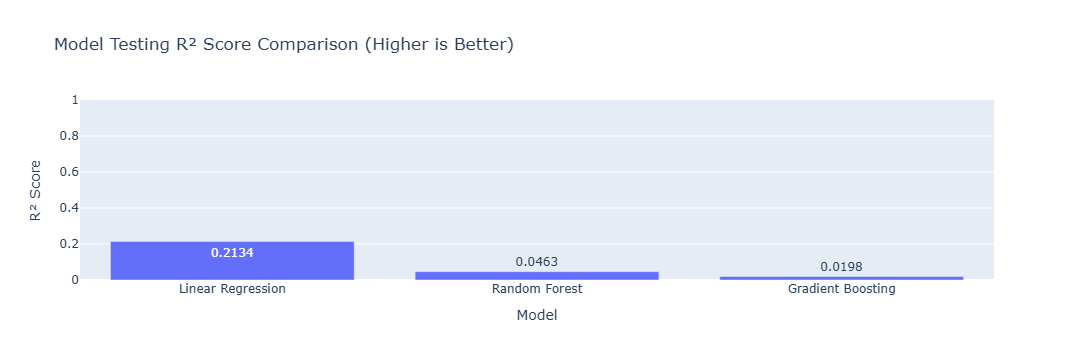

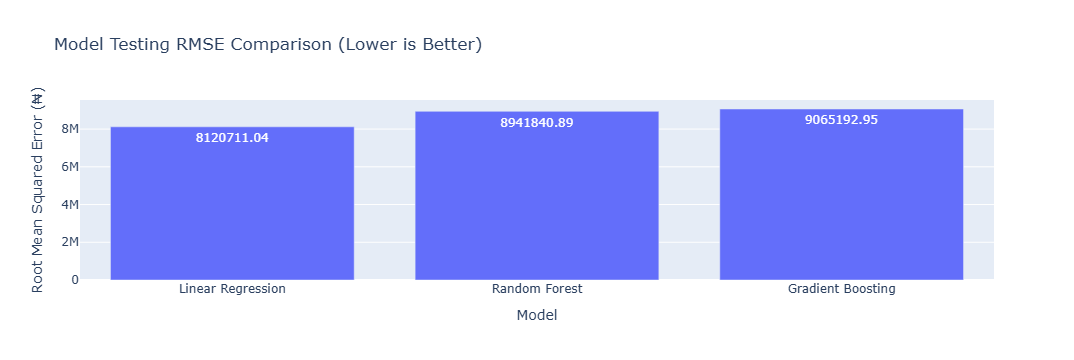

SAVING MODEL ARTIFACTS
✓ Linear Regression Model Saved
✓ Random Forest Model Saved
✓ Gradient Boosting Model Saved
✓ Scaler Saved
✓ Label Encoder Saved
✓ Feature Columns Saved
✓ Model Saved

All Model Artifacts Saved Successfully.

Testing Predictions 1...

LINEAR REGRESSION PREDICTION

Predicted Medical Cost: ₦13,326,360.53

Testing Predictions 2...

LINEAR REGRESSION PREDICTION

Predicted Medical Cost: ₦7,877,665.73

Testing Predictions 3...

LINEAR REGRESSION PREDICTION

Predicted Medical Cost: ₦14,695,174.84

Testing Predictions 4...

RANDOM FOREST PREDICTION

Predicted Medical Cost: ₦30,378,139.68

Testing Predictions 5...

LINEAR REGRESSION PREDICTION

Predicted Medical Cost: ₦7,877,665.73

Testing Predictions 6...

LINEAR REGRESSION PREDICTION

Predicted Medical Cost: ₦14,695,174.84

Testing Predictions 7...

GRADIENT BOOSTING PREDICTION

Predicted Medical Cost: ₦25,294,900.16

Testing Predictions 8...

LINEAR REGRESSION PREDICTION

Predicted Medical Cost: ₦7,877,665.73

Testing

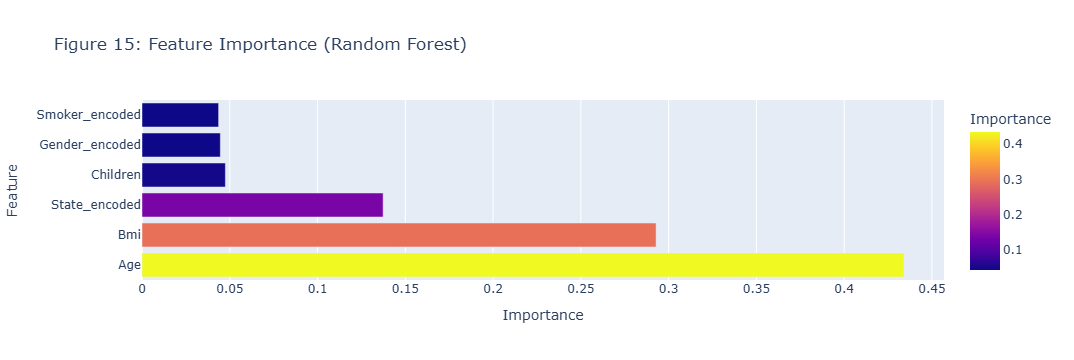

FACTORS INFLUENCING MEDICAL COST

Top Features Influencing Medical Cost:

Age : 0.4340
Bmi : 0.2929
State_encoded : 0.1374
Children : 0.0475
Gender_encoded : 0.0446
Smoker_encoded : 0.0436
FAIRNESS AND BIAS

Potential fairness and bias considerations include:

1. Gender bias
   The model may produce different predictions for males and females
   if the historical data contains unequal medical spending patterns.

2. State bias
   Healthcare costs may differ across Nigerian states due to
   differences in hospital pricing and healthcare accessibility.

3. Lifestyle bias
   Smokers generally incur higher medical costs. The model reflects
   these historical patterns, but predictions should not be used to
   unfairly discriminate against individuals.

4. Data quality
   Missing values, incorrect entries, or underrepresented groups
   can introduce bias into the model.

Recommendation:
Regularly audit the model using new data and fairness metrics to
ensure equitable predictions across all d

In [310]:
if __name__ == "__main__":
    main()

# Brief report explaining MODEL BUILDING (REGRESSION)

# Introduction

The objective of the model-building phase was to develop machine learning models capable of accurately predicting patients' **hospital bills** using demographic, lifestyle, and health-related factors. The target variable for this project was **Hospital_Bill**. Three regression algorithms were implemented and evaluated to determine the most suitable model for predicting medical insurance costs.

# Data Preparation

Before model training, the cleaned dataset was prepared for machine learning. Categorical variables such as **Gender, Smoker, and State** were encoded using Label Encoding to convert them into numerical values. The dataset was then divided into **training (80%) and testing (20%)** subsets using the **train_test_split()** function with a fixed random state to ensure reproducibility.

To improve the performance of Linear Regression, **numerical features were standardized using StandardScaler**. The Random Forest Regressor and Gradient Boosting Regressor were trained using the original **(unscaled) features since tree-based models are not affected by feature scaling**.

# Model Development

Three regression models were developed and trained:

**Linear Regression** was used as the baseline model to establish a benchmark for prediction performance.

**Random Forest Regressor** was implemented to capture nonlinear relationships and interactions among predictor variables through an ensemble of decision trees.

**Gradient Boosting Regressor** was developed to improve prediction accuracy by sequentially minimizing prediction errors through boosting.
Model Evaluation

The performance of each model was evaluated using the following regression metrics:

**Mean Absolute Error (MAE)**: Measures the average absolute difference between the predicted and actual hospital bills.
**Mean Squared Error (MSE)**: Measures the average squared prediction error, giving greater weight to larger errors.
**Root Mean Squared Error (RMSE)**: Represents the average prediction error in the same unit as the hospital bill, making it easier to interpret.
**Coefficient of Determination (R² Score)**: Indicates how well the model explains the variation in hospital bills. Higher R² values indicate better predictive performance.

The evaluation metrics of the three models were compared using summary tables and visualization charts.

# Model Comparison

The comparison showed differences in prediction accuracy among the three algorithms. 

**Linear Regression** provided a useful baseline but was limited in capturing complex nonlinear relationships within the data.

**Random Forest Regressor and Gradient Boosting Regressor** demonstrated superior predictive performance due to their ability to model nonlinear patterns and feature interactions.

The model with the highest R² score and the lowest **MAE, MSE, and RMSE** was selected as the best-performing model for deployment.

# Model Saving

After selecting the best-performing model, the trained models and preprocessing objects were saved using the Joblib library. The following artifacts were stored for deployment in the Streamlit application:

**Linear Regression model**

**Random Forest Regressor model**

**Gradient Boosting Regressor model**

**Standard Scaler**

**Label Encoders**

**Feature Columns**

**Model Encoders**

Saving these artifacts allows the trained models to be loaded directly into the Streamlit dashboard without retraining, improving efficiency and ensuring consistent predictions.

## Conclusion

The model-building phase successfully developed and evaluated three regression models for predicting medical insurance costs. Performance comparison identified the most accurate model based on standard regression metrics. The saved model artifacts provide a reliable foundation for the prediction system and will be integrated into the Streamlit dashboard to generate real-time hospital bill predictions based on user input.